[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/Machine-Learning-from-scratch/blob/master/topics/07_knn/first_principles.ipynb)

# 07 K-Nearest Neighbors — First Principles

**Goal.** Implement a KNN classifier from scratch using only NumPy, visualise how $K$
controls the decision boundary, cross-check against scikit-learn and the `src/` library
implementation, and explore failure cases: curse of dimensionality and feature scaling.

**Prerequisites.** [theory.md](theory.md) — distance metrics, K selection, weighted KNN,
curse of dimensionality, computational complexity.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 1. Problem Setup — WHY

Parametric models (linear/logistic regression) fit a fixed set of parameters and discard
the training data. KNN takes the opposite approach: **store everything, predict locally.**

For a new query $x_q$, find the $K$ closest training points and let them vote.
The decision boundary emerges from the local geometry of the data — no functional form
is assumed.

With $K = 1$, the decision boundary is a **Voronoi tessellation**: each region contains
the points closest to one training point.

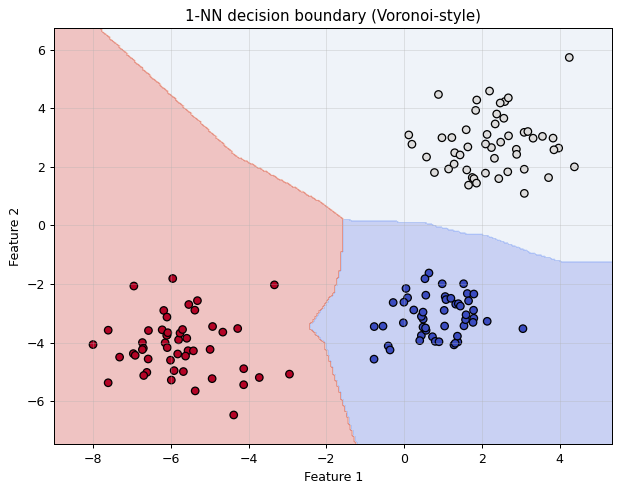

In [2]:
from ml_first_principles.data_utils import generate_classification_data
from ml_first_principles.visualization import plot_decision_boundary

# Generate a 2D, 3-class dataset for visualisation.
X_demo, y_demo = generate_classification_data(
    n_samples=150, n_features=2, n_classes=3, random_state=SEED
)


# Quick 1-NN using sklearn for the motivation plot.
from sklearn.neighbors import KNeighborsClassifier as SklearnKNN

knn_1 = SklearnKNN(n_neighbors=1).fit(X_demo, y_demo)
fig = plot_decision_boundary(knn_1, X_demo, y_demo,
                             title="1-NN decision boundary (Voronoi-style)")
plt.show()

**Reading.** The 1-NN boundary is jagged and wraps tightly around individual points.
Every training point creates its own Voronoi cell — zero training error, but high
variance (overfitting).

## 2. Mathematical Core — WHAT

Full derivations are in [theory.md](theory.md). Here we state the equations used in code.

**Euclidean distance:**

$$d_2(x, z) = \|x - z\|_2 = \sqrt{\sum_{j=1}^p (x_j - z_j)^2}$$

**KNN classification rule:**

$$\hat{y}(x_q) = \arg\max_c \sum_{i \in \mathcal{N}_K(x_q)} \mathbb{1}[y_i = c]$$

where $\mathcal{N}_K(x_q)$ is the set of $K$ training indices with smallest distance to $x_q$.

**No training phase.** There are no parameters to learn — the model *is* the stored data.

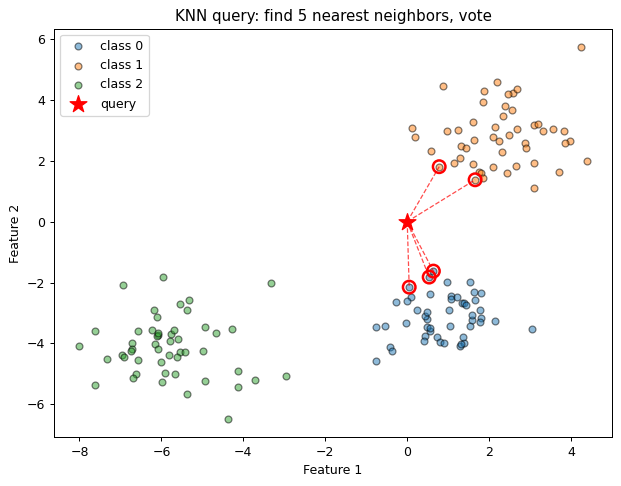

Neighbor labels: [0 0 1 0 1]
Distances: [1.746 1.898 1.968 2.152 2.154]
Vote: class 0 (counts: {np.int64(0): np.int64(3), np.int64(1): np.int64(2)})


In [3]:
# Visualise distance computation for a single query point.
x_query = np.array([0.0, 0.0])
distances = np.linalg.norm(X_demo - x_query, axis=1)
K = 5
nearest_idx = np.argpartition(distances, K - 1)[:K]

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = ["tab:blue", "tab:orange", "tab:green"]
for c in np.unique(y_demo):
    mask = y_demo == c
    ax.scatter(X_demo[mask, 0], X_demo[mask, 1], c=colors[c],
              label=f"class {c}", alpha=0.5, edgecolor="k", s=30)
ax.scatter(*x_query, c="red", marker="*", s=200, zorder=5, label="query")
for idx in nearest_idx:
    ax.plot([x_query[0], X_demo[idx, 0]], [x_query[1], X_demo[idx, 1]],
            "r--", lw=1, alpha=0.7)
    ax.scatter(X_demo[idx, 0], X_demo[idx, 1], s=100, facecolors="none",
              edgecolors="red", lw=2)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title(f"KNN query: find {K} nearest neighbors, vote")
ax.legend()
plt.tight_layout()
plt.show()

neighbor_labels = y_demo[nearest_idx]
print(f"Neighbor labels: {neighbor_labels}")
print(f"Distances: {distances[nearest_idx].round(3)}")
labels, counts = np.unique(neighbor_labels, return_counts=True)
print(f"Vote: class {labels[np.argmax(counts)]} (counts: {dict(zip(labels, counts))})")

## 3. Solution Method — HOW

KNN has no iterative solver — the algorithm is direct.

```
fit(X_train, y_train):
    Store X_train, y_train

predict(X_query):
    for each query x_q in X_query:
        d_i ← ||x_q - x_i||_2  for i = 1, …, n
        N_K ← indices of K smallest d_i  (argpartition)
        ŷ ← majority vote of y[N_K]
    return predictions
```

**Complexity per query:** $O(np)$ for distances + $O(n)$ for partial sort = $O(np)$.

## 4. Implementation — BUILD

### 4.1 From-scratch KNN classifier

In [4]:
class KNNClassifierScratch:
    """K-Nearest Neighbors classifier (brute-force, Euclidean distance)."""

    def __init__(self, n_neighbors=5):
        if n_neighbors < 1:
            raise ValueError("n_neighbors must be >= 1")
        self.n_neighbors = n_neighbors
        self.X_train_ = None
        self.y_train_ = None

    def fit(self, X, y):
        """Store the training set (no computation)."""
        self.X_train_ = np.asarray(X, dtype=float)
        self.y_train_ = np.asarray(y)
        if self.X_train_.ndim != 2:
            raise ValueError("X must be 2D")
        if self.X_train_.shape[0] != self.y_train_.shape[0]:
            raise ValueError("X and y must have the same number of samples")
        if self.n_neighbors > self.X_train_.shape[0]:
            raise ValueError("n_neighbors exceeds training set size")
        return self

    def predict(self, X):
        """Predict by majority vote of K nearest neighbors."""
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != self.X_train_.shape[1]:
            raise ValueError("X has incompatible feature shape")
        predictions = []
        for x_q in X:
            # Euclidean distances to all training points.
            distances = np.linalg.norm(self.X_train_ - x_q, axis=1)
            # Partial sort: O(n) instead of O(n log n).
            nearest_idx = np.argpartition(distances, self.n_neighbors - 1)[:self.n_neighbors]
            # Majority vote.
            neighbor_labels = self.y_train_[nearest_idx]
            labels, counts = np.unique(neighbor_labels, return_counts=True)
            predictions.append(labels[np.argmax(counts)])
        return np.array(predictions)

    def score(self, X, y):
        """Classification accuracy."""
        return float(np.mean(self.predict(X) == np.asarray(y)))

In [5]:
# Smoke test: 1-NN should achieve 100% training accuracy.
knn_1nn = KNNClassifierScratch(n_neighbors=1).fit(X_demo, y_demo)
train_acc = knn_1nn.score(X_demo, y_demo)
print(f"1-NN training accuracy: {train_acc:.4f}")
assert np.isclose(train_acc, 1.0, atol=1e-12), "1-NN must achieve 100% train accuracy"

1-NN training accuracy: 1.0000


### 4.2 Effect of K on the decision boundary

Increasing $K$ smooths the boundary: $K = 1$ overfits, large $K$ underfits.

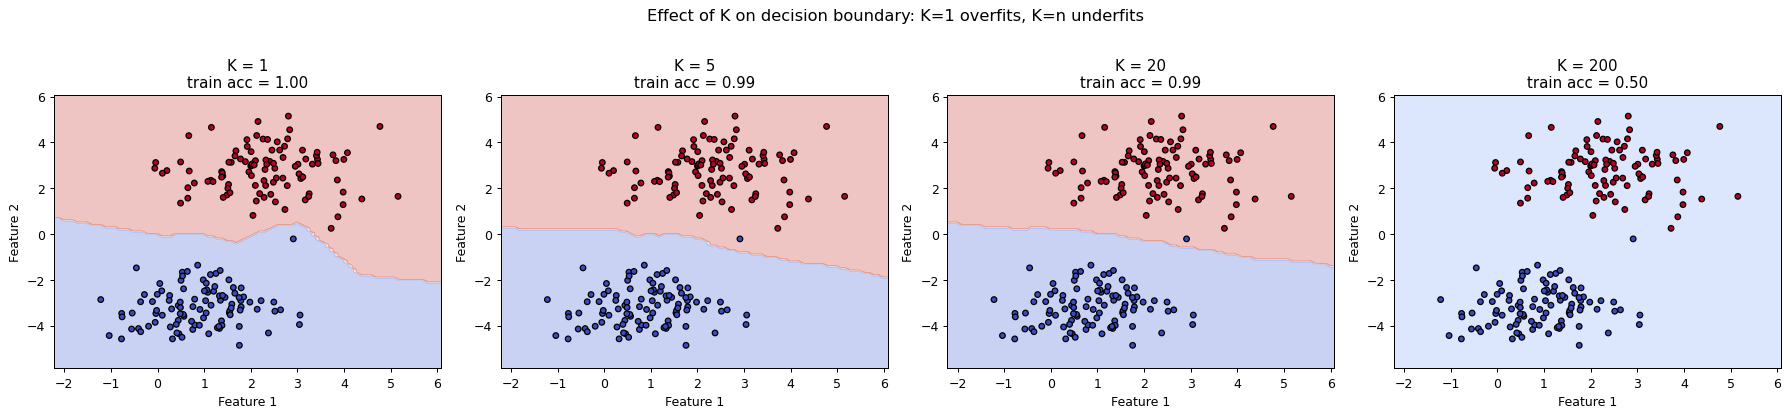

In [6]:
# Generate a simpler 2-class dataset for clearer boundary visualisation.
X_2c, y_2c = generate_classification_data(
    n_samples=200, n_features=2, n_classes=2, random_state=SEED
)

K_values = [1, 5, 20, X_2c.shape[0]]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, K in zip(axes, K_values):
    model = KNNClassifierScratch(n_neighbors=K).fit(X_2c, y_2c)
    train_acc = model.score(X_2c, y_2c)

    # Decision boundary via mesh grid.
    x_min, x_max = X_2c[:, 0].min() - 1, X_2c[:, 0].max() + 1
    y_min, y_max = X_2c[:, 1].min() - 1, X_2c[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_2c[:, 0], X_2c[:, 1], c=y_2c, cmap="coolwarm",
              edgecolor="k", s=20)
    ax.set_title(f"K = {K}\ntrain acc = {train_acc:.2f}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.suptitle("Effect of K on decision boundary: K=1 overfits, K=n underfits",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Reading.**
- **K=1:** Jagged boundary, 100% train accuracy (overfitting).
- **K=5:** Smoother boundary, captures the main cluster structure.
- **K=20:** Even smoother, starts losing fine-grained detail.
- **K=n:** Constant prediction (majority class), boundary disappears.

## 5. Library Comparison

Cross-check our from-scratch implementation against:
1. `ml_first_principles.distance_models.KNeighborsClassifier` (src/ library)
2. `sklearn.neighbors.KNeighborsClassifier`

In [7]:
from ml_first_principles.distance_models import KNeighborsClassifier as LibKNN
from sklearn.neighbors import KNeighborsClassifier as SklearnKNN

# Train/test split.
from ml_first_principles.data_utils import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X_2c, y_2c, test_size=0.2, random_state=SEED)

for K in [1, 3, 5, 11]:
    scratch = KNNClassifierScratch(n_neighbors=K).fit(X_tr, y_tr)
    lib = LibKNN(n_neighbors=K).fit(X_tr, y_tr)
    skl = SklearnKNN(n_neighbors=K).fit(X_tr, y_tr)

    pred_scratch = scratch.predict(X_te)
    pred_lib = lib.predict(X_te)
    pred_skl = skl.predict(X_te)

    # All three must produce identical predictions.
    match_lib = np.all(pred_scratch == pred_lib)
    match_skl = np.all(pred_scratch == pred_skl)

    acc = float(np.mean(pred_scratch == y_te))
    print(f"K={K:2d} | acc={acc:.3f} | match lib={match_lib} | match sklearn={match_skl}")
    assert match_lib, f"K={K}: scratch and lib disagree"
    assert match_skl, f"K={K}: scratch and sklearn disagree"

K= 1 | acc=1.000 | match lib=True | match sklearn=True
K= 3 | acc=1.000 | match lib=True | match sklearn=True
K= 5 | acc=1.000 | match lib=True | match sklearn=True
K=11 | acc=1.000 | match lib=True | match sklearn=True


**Reading.** All three implementations produce identical predictions for every $K$.
This validates our from-scratch implementation.

## 6. Experiments and Failures — VERIFY

### 6.1 Curse of dimensionality

We add random irrelevant features to a 2D problem and watch accuracy degrade.

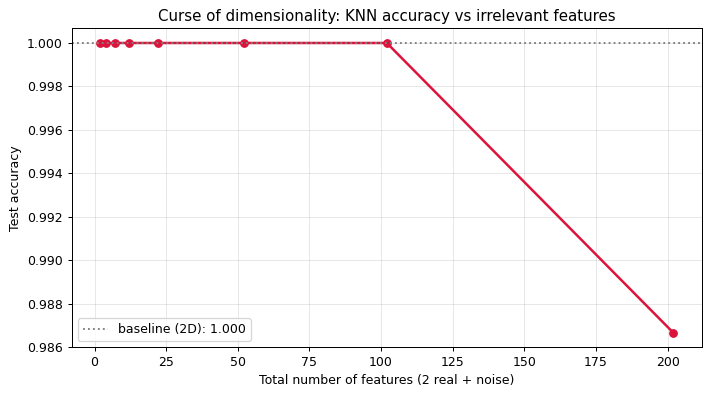

2D accuracy:    1.000
202D accuracy:  0.987
Degradation:    0.013


In [8]:
# Start with the clean 2D dataset.
X_base, y_base = generate_classification_data(
    n_samples=300, n_features=2, n_classes=2, random_state=SEED
)
X_tr_base, X_te_base, y_tr_base, y_te_base = train_test_split(
    X_base, y_base, test_size=0.25, random_state=SEED
)

noise_dims = [0, 2, 5, 10, 20, 50, 100, 200]
accuracies = []

for n_noise in noise_dims:
    # Append random noise features.
    X_tr_aug = np.hstack([X_tr_base, rng.normal(size=(X_tr_base.shape[0], n_noise))]) if n_noise > 0 else X_tr_base.copy()
    X_te_aug = np.hstack([X_te_base, rng.normal(size=(X_te_base.shape[0], n_noise))]) if n_noise > 0 else X_te_base.copy()

    knn = KNNClassifierScratch(n_neighbors=5).fit(X_tr_aug, y_tr_base)
    acc = knn.score(X_te_aug, y_te_base)
    accuracies.append(acc)

fig, ax = plt.subplots(figsize=(8, 4.5))
total_dims = [2 + d for d in noise_dims]
ax.plot(total_dims, accuracies, "o-", color="crimson", lw=2)
ax.axhline(accuracies[0], color="gray", ls=":", label=f"baseline (2D): {accuracies[0]:.3f}")
ax.set_xlabel("Total number of features (2 real + noise)")
ax.set_ylabel("Test accuracy")
ax.set_title("Curse of dimensionality: KNN accuracy vs irrelevant features")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"2D accuracy:    {accuracies[0]:.3f}")
print(f"202D accuracy:  {accuracies[-1]:.3f}")
print(f"Degradation:    {accuracies[0] - accuracies[-1]:.3f}")

**Reading.** Accuracy drops steadily as noise dimensions are added. With 200 noise
features, distances are dominated by irrelevant dimensions and KNN degrades toward
random guessing. This is the curse of dimensionality in action (theory.md §5).

### 6.2 Distance concentration in high dimensions

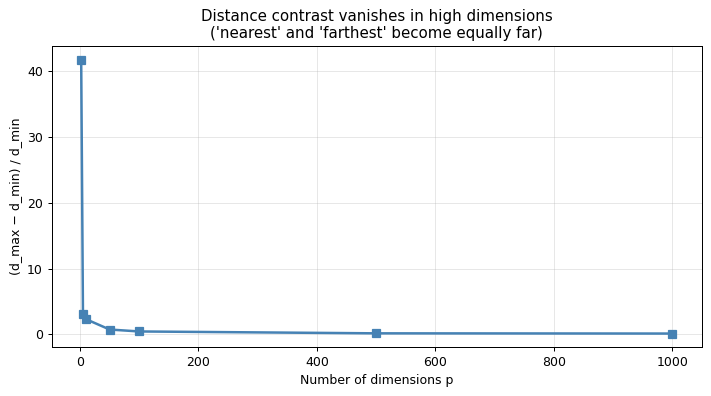

p=2:    contrast = 41.718
p=1000: contrast = 0.128


In [9]:
# Show that distances concentrate as dimensionality grows.
dimensions = [2, 5, 10, 50, 100, 500, 1000]
relative_contrasts = []

for p in dimensions:
    points = rng.normal(size=(200, p))
    query = rng.normal(size=p)
    dists = np.linalg.norm(points - query, axis=1)
    contrast = (dists.max() - dists.min()) / dists.min()
    relative_contrasts.append(contrast)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dimensions, relative_contrasts, "s-", color="steelblue", lw=2)
ax.set_xlabel("Number of dimensions p")
ax.set_ylabel("(d_max − d_min) / d_min")
ax.set_title("Distance contrast vanishes in high dimensions\n"
             "('nearest' and 'farthest' become equally far)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"p=2:    contrast = {relative_contrasts[0]:.3f}")
print(f"p=1000: contrast = {relative_contrasts[-1]:.3f}")

**Reading.** In 2D, the farthest point is many times farther than the nearest. In 1000D,
the contrast shrinks dramatically — all points are roughly equidistant. The concept of
"nearest neighbor" becomes meaningless.

### 6.3 Failure case: unscaled features

In [10]:
# Create a dataset where feature scales differ dramatically.
# Feature 1: informative, range [0, 1]
# Feature 2: informative, range [0, 1000]
n_scale = 300
rng_scale = np.random.default_rng(SEED)
X_scale_raw = rng_scale.normal(size=(n_scale, 2))
# True boundary depends equally on both features.
y_scale = ((X_scale_raw[:, 0] + X_scale_raw[:, 1]) > 0).astype(int)

# Rescale feature 2 to [0, 1000].
X_unscaled = X_scale_raw.copy()
X_unscaled[:, 1] *= 1000

# Standardised version.
from ml_first_principles.data_utils import standardize
X_scaled, mu, sigma = standardize(X_unscaled)

X_tr_u, X_te_u, y_tr_s, y_te_s = train_test_split(
    X_unscaled, y_scale, test_size=0.25, random_state=SEED
)
X_tr_s, X_te_s = (X_tr_u - mu) / sigma, (X_te_u - mu) / sigma

knn_unscaled = KNNClassifierScratch(n_neighbors=5).fit(X_tr_u, y_tr_s)
knn_scaled = KNNClassifierScratch(n_neighbors=5).fit(X_tr_s, y_tr_s)

acc_unscaled = knn_unscaled.score(X_te_u, y_te_s)
acc_scaled = knn_scaled.score(X_te_s, y_te_s)

print(f"KNN on unscaled features: accuracy = {acc_unscaled:.3f}")
print(f"KNN on scaled features:   accuracy = {acc_scaled:.3f}")
print(f"Scaling improvement:      {acc_scaled - acc_unscaled:+.3f}")

KNN on unscaled features: accuracy = 0.693
KNN on scaled features:   accuracy = 0.947
Scaling improvement:      +0.253


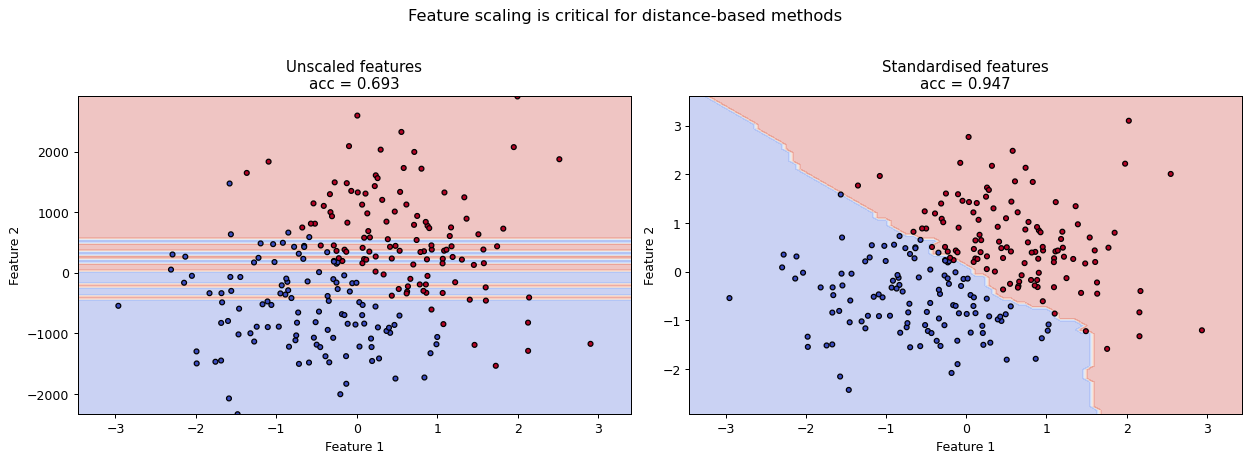

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X_train, X_test, title, acc in [
    (axes[0], X_tr_u, X_te_u, "Unscaled", acc_unscaled),
    (axes[1], X_tr_s, X_te_s, "Standardised", acc_scaled),
]:
    knn_tmp = KNNClassifierScratch(n_neighbors=5).fit(X_train, y_tr_s)
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    # Grid each axis with 80 points: a single step derived from the x-range
    # would blow up the unscaled panel, whose y-axis spans ~1000x more.
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80),
                         np.linspace(y_min, y_max, 80))
    Z = knn_tmp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_tr_s, cmap="coolwarm",
              edgecolor="k", s=15)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(f"{title} features\nacc = {acc:.3f}")

plt.suptitle("Feature scaling is critical for distance-based methods",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Reading.** Without standardisation, the feature with range [0, 1000] completely
dominates the distance computation. The boundary becomes nearly horizontal — ignoring
the informative feature 1 entirely. After standardisation, both features contribute
equally, and accuracy improves substantially.

### 6.4 K selection by cross-validation

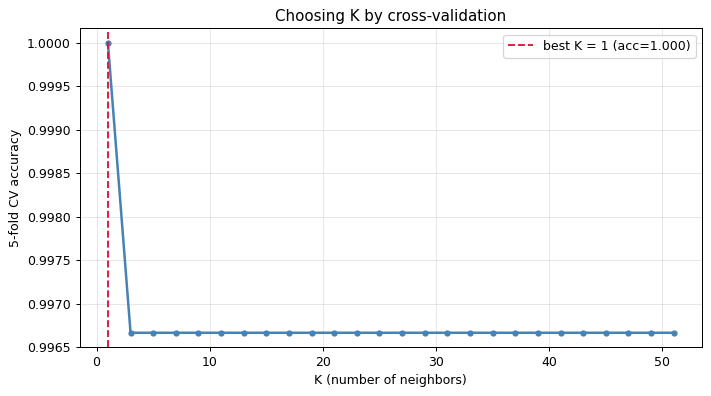

Best K = 1, CV accuracy = 1.000


In [12]:
from ml_first_principles.data_utils import k_fold_split

X_cv, y_cv = generate_classification_data(
    n_samples=300, n_features=2, n_classes=2, random_state=SEED
)

K_range = list(range(1, 52, 2))  # odd K to avoid ties
mean_accs = []

for K in K_range:
    fold_accs = []
    for train_idx, val_idx in k_fold_split(X_cv, y_cv, k=5, random_state=SEED):
        knn = KNNClassifierScratch(n_neighbors=K).fit(X_cv[train_idx], y_cv[train_idx])
        fold_accs.append(knn.score(X_cv[val_idx], y_cv[val_idx]))
    mean_accs.append(np.mean(fold_accs))

best_K = K_range[np.argmax(mean_accs)]
best_acc = max(mean_accs)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(K_range, mean_accs, "o-", color="steelblue", lw=2, markersize=4)
ax.axvline(best_K, color="crimson", ls="--", label=f"best K = {best_K} (acc={best_acc:.3f})")
ax.set_xlabel("K (number of neighbors)")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Choosing K by cross-validation")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best K = {best_K}, CV accuracy = {best_acc:.3f}")

**Reading.** CV accuracy typically rises from K=1 (overfitting) to a moderate K, then
decreases as K becomes too large (underfitting). The optimal K balances bias and variance.

## 7. Connections

| Concept | Connection |
|---|---|
| **K-Means clustering** | Both distance-based: KNN uses nearest *data points*, K-Means uses nearest *centroids* |
| **Decision trees** | Both non-parametric with piecewise-constant predictions; trees split on axes, KNN on distance spheres |
| **SVM / kernel methods** | Kernel similarity is analogous to distance-based neighbors |
| **Bias-variance tradeoff** | $K$ plays the same role as $\lambda$ in regularised models |
| **Dimensionality reduction (PCA)** | Cure for the curse of dimensionality before KNN |

### Takeaway

KNN is conceptually the simplest classifier: **store data, find nearest, vote.** Its
simplicity reveals fundamental concepts — the curse of dimensionality, the bias-variance
tradeoff via K, and the critical importance of feature scaling for distance-based methods.
These lessons apply to any distance-based algorithm.